## Clone fate


PLCO

N clones per group:
 Low peak start    536
P-CH start        406
MGUS start        361
Name: start_group, dtype: int64

Counts:
 fate            Disappeared  Decreased  Persistent  Increased
start_group                                                  
Low peak start          268          0         209         59
P-CH start              134         33         173         66
MGUS start               15         17          95        234

Row % :
 fate            Disappeared  Decreased  Persistent  Increased
start_group                                                  
Low peak start         50.0        0.0        39.0       11.0
P-CH start             33.0        8.1        42.6       16.3
MGUS start              4.2        4.7        26.3       64.8

Global chi2=451.92, df=6, P=1.89e-94

-----------------------------------------------------------------
Category-Specific Rates & Pairwise Fisher's Tests
(* Odds Ratios are calculated with 'P-CH' as the reference *)
-----------------

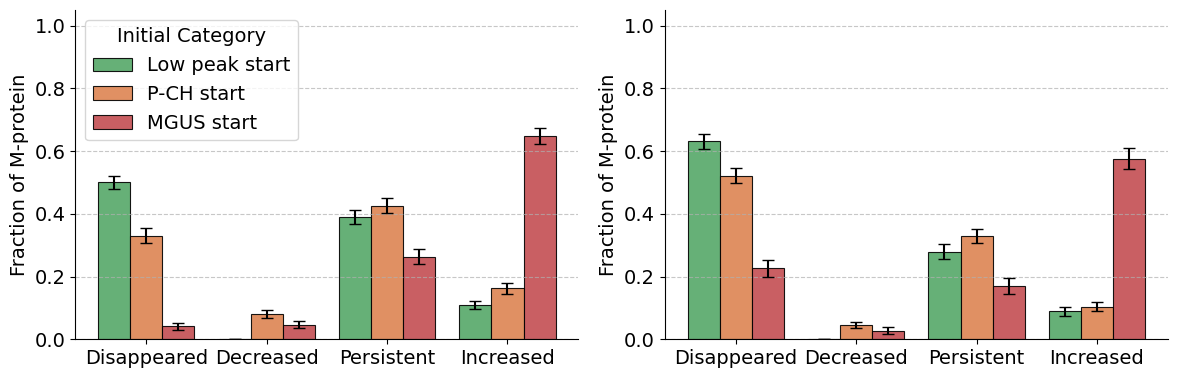

In [2]:
import math
import pandas as pd
import numpy as np
from itertools import combinations

FATE_ORDER = {'Negative': 0, 'Low_MS': 1, 'MGIP': 2, 'MS-MGUS': 3}
FATE_LIST = ['Disappeared', 'Decreased', 'Persistent', 'Increased']

def _gammainc_lower_reg(a, x):
    if x < a + 1:
        ap, summ, delta = a, 1.0 / a, 1.0 / a
        for _ in range(500):
            ap += 1
            delta *= x / ap
            summ += delta
            if abs(delta) < abs(summ) * 1e-14:
                break
        return summ * math.exp(-x + a * math.log(x) - math.lgamma(a))
    return 1.0 - _gammainc_upper_cf(a, x)

def _gammainc_upper_cf(a, x):
    tiny = 1e-300
    b, c, d = x + 1 - a, 1 / tiny, 1 / (x + 1 - a)
    h = d
    for i in range(1, 500):
        an = -i * (i - a)
        b += 2
        d = an * d + b
        if abs(d) < tiny: d = tiny
        c = b + an / c
        if abs(c) < tiny: c = tiny
        d = 1 / d
        delta = d * c
        h *= delta
        if abs(delta - 1) < 1e-14:
            break
    return h * math.exp(-x + a * math.log(x) - math.lgamma(a))

def chi2_sf(x, df):
    if x <= 0: return 1.0
    a, xx = df / 2.0, x / 2.0
    if xx < a + 1: return 1.0 - _gammainc_lower_reg(a, xx)
    return _gammainc_upper_cf(a, xx)

def pearson_chi2(ct):
    obs = ct.values.astype(float)
    row_tot, col_tot, grand = obs.sum(1, keepdims=True), obs.sum(0, keepdims=True), obs.sum()
    exp = row_tot @ col_tot / grand
    exp[exp == 0] = 1e-9
    stat = ((obs - exp) ** 2 / exp).sum()
    df = (obs.shape[0] - 1) * (obs.shape[1] - 1)
    p = chi2_sf(stat, df) if df > 0 else 1.0
    return stat, df, p

def fisher_exact_2x2(a, b, c, d):
    r1, r2, c1, c2, n = a + b, c + d, a + c, b + d, a + b + c + d
    lo, hi = max(0, c1 - r2), min(r1, c1)

    def log_pmf(k):
        return (math.lgamma(r1 + 1) - math.lgamma(k + 1) - math.lgamma(r1 - k + 1)
                + math.lgamma(r2 + 1) - math.lgamma(c1 - k + 1) - math.lgamma(r2 - c1 + k + 1)
                - (math.lgamma(n + 1) - math.lgamma(c1 + 1) - math.lgamma(n - c1 + 1)))

    obs_log = log_pmf(a)
    p = sum(math.exp(log_pmf(k)) for k in range(lo, hi + 1) if log_pmf(k) <= obs_log + 1e-8)
    odds = (a * d) / (b * c) if b * c > 0 else float('inf')
    return min(p, 1.0), odds

def print_pairwise_fate_tests(ct):
    print("\n" + "-"*65)
    print("Category-Specific Rates & Pairwise Fisher's Tests")
    print("(* Odds Ratios are calculated with 'P-CH' as the reference *)")
    print("-" * 65)
    
    groups = [g for g in ct.index if ct.loc[g].sum() > 0]
    if len(groups) < 2:
        print("Not enough populated groups for pairwise comparison.")
        return

    # Find the reference group name
    ref_name = next((g for g in groups if 'P-CH' in g), None)

    for fate in FATE_LIST:
        print(f"\n[ {fate} ]")
        fate_data = {}
        for g in groups:
            a = int(ct.loc[g, fate])
            b = int(ct.loc[g, FATE_LIST].sum() - a)
            fate_data[g] = (a, b)
            rate = 100 * a / (a + b) if (a + b) > 0 else 0.0
            print(f"  {g}: {rate:.1f}% ({a}/{a+b})")

        print(f"  Pairwise comparisons ({fate} vs. not {fate}):")
        for g1, g2 in combinations(groups, 2):
            # If g1 is the reference, swap so it becomes g2 (denominator)
            if ref_name and g1 == ref_name:
                g1, g2 = g2, g1
                
            a, b = fate_data[g1]
            c, d = fate_data[g2]
            p_fisher, odds = fisher_exact_2x2(a, b, c, d)
            
            # Add "(ref)" tag if compared against the reference group
            ref_tag = " (ref)" if g2 == ref_name else ""
            print(f"    {g1} vs {g2}{ref_tag} -> OR: {odds:.2f}, P: {p_fisher:.3g}")

def conc_category(conc, bs_thresh, mgip_thresh):
    if conc >= bs_thresh: return 'MS-MGUS'
    if conc >= mgip_thresh: return 'MGIP'
    return 'Low_MS'

def analyze_cohort(raw_df, person_col, clone_col, time_col, conc_col, mz_col,
                   bs_col, mgip_col, bigger_time_is_later, cohort_name):
    
    raw = raw_df.copy()
    raw[time_col] = pd.to_numeric(raw[time_col], errors='coerce').round(6)
    raw[conc_col] = pd.to_numeric(raw[conc_col], errors='coerce')

    sign = 1 if bigger_time_is_later else -1
    raw['_t'] = raw[time_col] * sign

    visits = (raw.dropna(subset=[person_col, '_t'])
                 .groupby(person_col)['_t'].apply(lambda s: sorted(set(s))))

    real = raw.dropna(subset=[person_col, clone_col, '_t', conc_col, mz_col, bs_col, mgip_col]).copy()
    real = real[(real[mz_col] > 0) & (real[conc_col] > 0)].copy()
    real['cat'] = [conc_category(c, b, m) for c, b, m in
                   zip(real[conc_col], real[bs_col], real[mgip_col])]

    records = []
    for (person, clone), g in real.groupby([person_col, clone_col]):
        g = g.sort_values('_t')
        
        start_t = g['_t'].iloc[0]
        start_cat = g['cat'].iloc[0]
        start_conc = g[conc_col].iloc[0]

        pv = visits.get(person, [])
        window = [t for t in pv if t >= start_t]
        if len(window) < 2:
            continue

        detected_cat_at = dict(zip(g['_t'], g['cat']))
        detected_conc_at = dict(zip(g['_t'], g[conc_col]))
        
        end_t = window[-1]
        end_cat = detected_cat_at.get(end_t, 'Negative')
        end_conc = detected_conc_at.get(end_t, 0.0)

        if end_cat == 'Negative':
            fate = 'Disappeared'
        else:
            s, e = FATE_ORDER[start_cat], FATE_ORDER[end_cat]
            if e > s:
                fate = 'Increased'
            elif e < s:
                fate = 'Decreased'
            else:
                if start_cat == 'MS-MGUS' and end_conc > start_conc:
                    fate = 'Increased'
                else:
                    fate = 'Persistent'

        records.append({'person': person, 'clone_id': clone, 'start_cat': start_cat,
                         'end_cat': end_cat, 'n_visits_since_start': len(window), 'fate': fate})

    traj = pd.DataFrame(records)
    label = {'Low_MS': 'Low peak start', 'MGIP': 'P-CH start', 'MS-MGUS': 'MGUS start'}
    order = ['Low peak start', 'P-CH start', 'MGUS start']
    traj['start_group'] = traj['start_cat'].map(label)

    ct = pd.crosstab(traj['start_group'], traj['fate']).reindex(order)
    for col in FATE_LIST:
        if col not in ct.columns:
            ct[col] = 0
    ct = ct[FATE_LIST]

    print(f"\n{'='*74}\n{cohort_name}\n{'='*74}")
    print("\nN clones per group:\n", traj['start_group'].value_counts().reindex(order))
    print("\nCounts:\n", ct)
    pct = ct.div(ct.sum(1), axis=0) * 100
    print("\nRow % :\n", pct.round(1))
    
    stat, df, p = pearson_chi2(ct)
    print(f"\nGlobal chi2={stat:.2f}, df={df}, P={p:.3g}")
    print_pairwise_fate_tests(ct)

    return traj, ct


PROMISE_PATH = "../data/PROMISE_ms_clone.csv"
PLCO_PATH = "../data/PLCO_ms_clone.csv"

plco = pd.read_csv(PLCO_PATH, low_memory=False)
plco_traj, plco_ct = analyze_cohort(
    plco, person_col='e_2021_1015_id', clone_col='Clone_ID', time_col='Yr_before_dx',
    conc_col='Conc_1', mz_col='m.z_1', bs_col='bs_thresh', mgip_col='mgip_thresh',
    bigger_time_is_later=False, cohort_name="PLCO")

promise = pd.read_csv(PROMISE_PATH, low_memory=False)
promise_traj, promise_ct = analyze_cohort(
    promise, person_col='PROMISE_ID', clone_col='clone_id', time_col='yrs_from_baseline',
    conc_col='Conc', mz_col='m.z', bs_col='bs_thresh', mgip_col='mgip_thresh',
    bigger_time_is_later=True, cohort_name="PROMISE")


##### Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.rcParams.update({
    'font.size': 14,          
    'axes.titlesize': 14,        
    'axes.labelsize': 14,          
    'xtick.labelsize': 14,         
    'ytick.labelsize': 14,         
    'legend.fontsize': 14,         
    'legend.title_fontsize': 14,   
})

colors = sns.color_palette("deep", n_colors=10)
node_colors_dict = {
    'Negative'  : colors[0],
    '<LLMI'     : 'grey',
    'Artifact'  : 'lightgrey',
    'Low peak'  : colors[2],
    'P-CH'      : colors[1],
    'MGUS'      : colors[3],
}


start_group_colors = {
    'Low peak start'   : node_colors_dict['Low peak'],
    'P-CH start': node_colors_dict['P-CH'],
    'MGUS start'       : node_colors_dict['MGUS']
}


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

def plot_fate_fractions(ax, ct, title):
    start_groups = [g for g in ct.index if ct.loc[g].sum() > 0]
    fates = ct.columns
    
    n_groups = len(start_groups)
    n_fates = len(fates)
    bar_width = 0.8 / n_groups 
    
    x = np.arange(n_fates)
    
    for i, sg in enumerate(start_groups):
        n = ct.loc[sg].sum()
        counts = ct.loc[sg].values
        
        p = counts / n if n > 0 else np.zeros(n_fates)
        se = np.sqrt(p * (1 - p) / n) if n > 0 else np.zeros(n_fates)
        
        x_pos = x + (i - n_groups/2 + 0.5) * bar_width
        
        ax.bar(
            x_pos, p, 
            width=bar_width, 
            yerr=se, 
            label=sg, 
            color=start_group_colors[sg], 
            capsize=4, 
            edgecolor='black',
            linewidth=0.8,
            alpha=0.9
        )
    
    ax.set_xticks(x)
    ax.set_xticklabels(fates)
    ax.set_ylabel('Fraction of M-protein')
    #ax.set_title(title, pad=10)
    ax.set_ylim(0, 1.05) 
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plot_fate_fractions(axes[0], plco_ct, 'PLCO Cohort')
plot_fate_fractions(axes[1], promise_ct, 'PROMISE Cohort')

axes[0].legend(title='Initial Category')

plt.tight_layout()
plt.savefig("../00.Figures/Clone_Fates_Fraction.pdf") 
plt.show()

